# 18 · Risk measurement and performance attribution

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/18_risk_and_attribution.ipynb)

A portfolio is only half the job; the other half is knowing how much you can lose and explaining what happened.
This notebook covers what a risk or performance team does every day: VaR and Expected Shortfall three ways,
Monte Carlo simulation, backtesting a VaR model, risk decomposition, stress tests, drawdowns, a factor risk model,
and performance attribution (Brinson and returns-based).

**Portfolio:** a balanced Swiss multi-asset portfolio (weights below), on the same daily data as notebook 17.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


In [2]:
USE_REAL_DATA = False     # True = download real ETF prices from Yahoo Finance (the exercise checks need False)
ETFS = {"SPY": "US equity", "EFA": "Developed ex-US equity", "EEM": "EM equity", "AGG": "US bonds",
        "TLT": "Long Treasuries", "GLD": "Gold", "VNQ": "Real estate", "DBC": "Commodities"}

def load_returns():
    if USE_REAL_DATA:
        try:
            import subprocess, sys
            try:
                import yfinance as yf
            except ImportError:
                subprocess.run([sys.executable, "-m", "pip", "install", "-q", "yfinance"], check=False)
                import yfinance as yf
            px = yf.download(list(ETFS), start="2010-01-01", end="2024-12-31", auto_adjust=True, progress=False)["Close"]
            r = px.pct_change().dropna(how="all").dropna(axis=1, thresh=1000).dropna()
            if len(r) > 500:
                print("Using real ETF data from Yahoo Finance")
                return r
        except Exception as e:
            print("Download failed:", repr(e)[:150])
        print("Falling back to the bundled dataset")
    return pd.read_csv(DATA + "asset_returns_daily.csv", index_col=0, parse_dates=True)

rets = load_returns()
assets = list(rets.columns); n = len(assets)
print(rets.shape, rets.index[0].date(), "to", rets.index[-1].date())

(3912, 8) 2010-01-04 to 2024-12-31


In [3]:
from scipy import stats
W = pd.Series({"CH_EQUITY": 0.20, "WORLD_EQUITY": 0.20, "EM_EQUITY": 0.05, "CHF_BONDS": 0.25,
               "GLOBAL_BONDS": 0.10, "GOLD": 0.05, "SWISS_REAL_ESTATE": 0.10, "COMMODITIES": 0.05})
if not set(W.index) <= set(rets.columns):        # real ETF data: fall back to equal weights
    W = pd.Series(1 / n, index=rets.columns)
port = rets[W.index] @ W                         # daily portfolio returns (daily rebalanced to W)
VALUE = 100_000_000                              # CHF 100 million
print(f"annual return {port.mean() * 252:.2%}, volatility {port.std() * np.sqrt(252):.2%}")

annual return 5.26%, volatility 8.65%


## 1. Returns are not normal
VaR methods differ mostly in how they treat the tails. Look at the tails first.

skewness 0.28 | excess kurtosis 5.06 (normal = 0)
Jarque-Bera p-value: 0.0


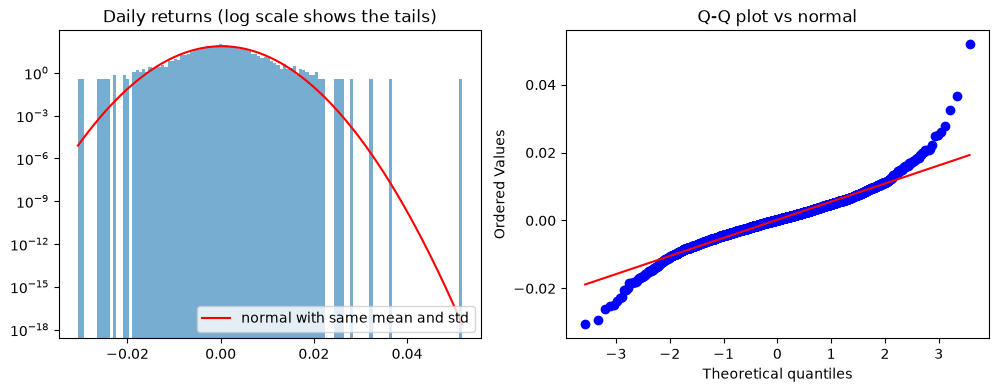

In [4]:
print(f"skewness {stats.skew(port):.2f} | excess kurtosis {stats.kurtosis(port):.2f} (normal = 0)")
print("Jarque-Bera p-value:", stats.jarque_bera(port).pvalue)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(port, bins=120, density=True, alpha=0.6); xs = np.linspace(port.min(), port.max(), 300)
ax[0].plot(xs, stats.norm.pdf(xs, port.mean(), port.std()), "r", label="normal with same mean and std"); ax[0].legend(); ax[0].set_yscale("log"); ax[0].set_title("Daily returns (log scale shows the tails)")
stats.probplot(port, dist="norm", plot=ax[1]); ax[1].set_title("Q-Q plot vs normal"); plt.show()

## 2. Value at Risk and Expected Shortfall
**1-day 99% VaR:** the loss that is exceeded on only 1% of days. **Expected Shortfall (ES)**: the average loss on
those worst 1% of days. ES looks into the tail, which is why Basel III moved bank capital from VaR to ES.
Convention: report both as **positive** numbers (losses).

### Exercise 1

Compute the 1-day 99% **historical VaR** of `port`: minus the 1% quantile (`np.quantile(port, 0.01)`). Store it in `var_hist_99`.

In [5]:
# Your code here

In [6]:
check("18.1");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 18.1: not answered yet. Store your answer in `var_hist_99`.


### Exercise 2

Compute the 1-day 99% **historical Expected Shortfall**: minus the average of all returns at or below that 1% quantile. Store it in `es_hist_99`.

In [7]:
# Your code here

In [8]:
check("18.2");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 18.2: not answered yet. Store your answer in `es_hist_99`.


### Exercise 3

Compute the 1-day 99% **parametric (normal) VaR**: `-(port.mean() + stats.norm.ppf(0.01) * port.std())`. Store it in `var_norm_99`. Is it larger or smaller than the historical VaR, and why?

In [9]:
# Your code here

In [10]:
check("18.3");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 18.3: not answered yet. Store your answer in `var_norm_99`.


In [11]:
q = np.quantile(port, 0.01)
t_df, t_loc, t_scale = stats.t.fit(port)                       # Student-t captures fat tails
rows = {
    "Historical": (-q, -port[port <= q].mean()),
    "Normal": (-(port.mean() + stats.norm.ppf(0.01) * port.std()), -(port.mean() - port.std() * stats.norm.pdf(stats.norm.ppf(0.01)) / 0.01)),
    f"Student-t (df={t_df:.1f})": (-stats.t.ppf(0.01, t_df, t_loc, t_scale), np.nan),
}
tab = pd.DataFrame(rows, index=["VaR 99%", "ES 99%"]).T
tab["VaR in CHF"] = (tab["VaR 99%"] * VALUE).round(-3)
print(tab.round(4))
print(f"10-day VaR by the square-root-of-time rule: {tab.iloc[0, 0] * np.sqrt(10):.2%} (assumes independent days; volatility clustering breaks this)")

                    VaR 99%  ES 99%  VaR in CHF
Historical           0.0145  0.0185   1447000.0
Normal               0.0125  0.0143   1246000.0
Student-t (df=4.6)   0.0142     NaN   1415000.0
10-day VaR by the square-root-of-time rule: 4.58% (assumes independent days; volatility clustering breaks this)


## 3. Monte Carlo simulation
Simulate many possible days (or years) from a model of the joint asset returns. The model choice drives the tail: compare multivariate normal with multivariate Student-t.

MC normal            VaR99 0.0125  ES99 0.0143
MC Student-t (ν=4)   VaR99 0.0143  ES99 0.0200


1-year: median return 5.0%, P(loss > 10%) = 3.8%, 99% VaR = 14.0%


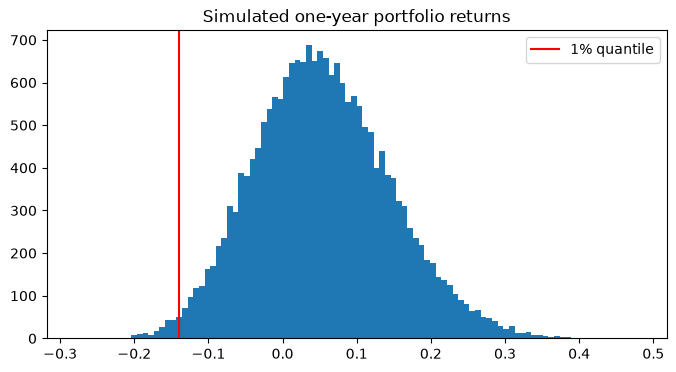

In [12]:
rng = np.random.default_rng(0)
m_d, S_d = rets[W.index].mean().to_numpy(), rets[W.index].cov().to_numpy()
N = 100_000
sim_norm = rng.multivariate_normal(m_d, S_d, N) @ W.to_numpy()
nu = 4                                                          # degrees of freedom for fat tails
z = rng.multivariate_normal(np.zeros(len(W)), S_d * (nu - 2) / nu, N)
sim_t = (m_d + z / np.sqrt(rng.chisquare(nu, N) / nu)[:, None]) @ W.to_numpy()
for name, s in [("MC normal", sim_norm), ("MC Student-t (ν=4)", sim_t)]:
    qq = np.quantile(s, 0.01); print(f"{name:20} VaR99 {-qq:.4f}  ES99 {-s[s <= qq].mean():.4f}")

# One-year horizon: bootstrap 252 historical days at a time
yrs = np.array([np.prod(1 + rng.choice(port.to_numpy(), 252)) - 1 for _ in range(20_000)])
print(f"1-year: median return {np.median(yrs):.1%}, P(loss > 10%) = {(yrs < -0.10).mean():.1%}, 99% VaR = {-np.quantile(yrs, 0.01):.1%}")
plt.hist(yrs, bins=100); plt.axvline(np.quantile(yrs, 0.01), color="r", label="1% quantile"); plt.legend(); plt.title("Simulated one-year portfolio returns"); plt.show()

## 4. Backtesting a VaR model
A 99% VaR should be exceeded on about 1% of days. Count the **exceptions** and test with **Kupiec's proportion-of-failures**
likelihood-ratio test:
$$LR = -2\left[\ln\big((1-p)^{n-x}p^{x}\big) - \ln\big((1-\hat p)^{n-x}\hat p^{x}\big)\right],\ \hat p = x/n,\quad LR \sim \chi^2_1$$

### Exercise 4

Write `kupiec_pvalue(x, n, p)` that returns the p-value of the Kupiec test for `x` exceptions in `n` days at VaR level `p` (e.g. 0.01). Handle the case x = 0 (then the x·ln(p̂) term is 0).

In [13]:
# Your code here

In [14]:
check("18.4");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 18.4: not answered yet. Store your answer in `kupiec_pvalue`.


HS    exceptions 53 of 3662 days (1.45%, expected 1%) | Kupiec p = 0.011
EWMA  exceptions 69 of 3662 days (1.88%, expected 1%) | Kupiec p = 0.000


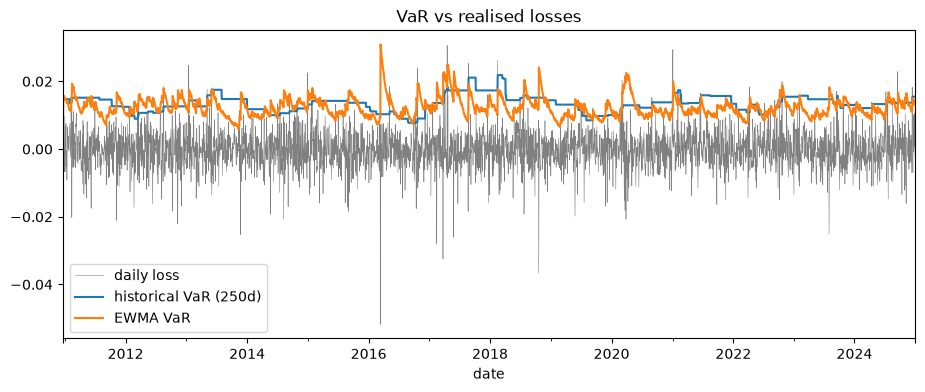

In [15]:
def _kupiec(x, n, p):                                          # reference version so the cell runs before Exercise 4
    pi = x / n
    ll0 = (n - x) * np.log(1 - p) + x * np.log(p)
    ll1 = (n - x) * np.log(1 - pi) + (x * np.log(pi) if x > 0 else 0.0)
    return 1 - stats.chi2.cdf(-2 * (ll0 - ll1), 1)

win = 250
var_hs = -port.rolling(win).quantile(0.01).shift(1)            # historical VaR known the day before
lam = 0.94                                                      # RiskMetrics EWMA volatility
ewma_var = (port ** 2).ewm(alpha=1 - lam, adjust=False).mean().shift(1)
var_ewma = -stats.norm.ppf(0.01) * np.sqrt(ewma_var)
test = pd.DataFrame({"r": port, "HS": var_hs, "EWMA": var_ewma}).dropna()
for m in ["HS", "EWMA"]:
    exc = (test["r"] < -test[m]); x, nn = int(exc.sum()), len(exc)
    print(f"{m:5} exceptions {x} of {nn} days ({x / nn:.2%}, expected 1%) | Kupiec p = {_kupiec(x, nn, 0.01):.3f}")
ax = (-test["r"]).plot(figsize=(11, 4), lw=0.4, color="grey", label="daily loss")
test["HS"].plot(ax=ax, label="historical VaR (250d)"); test["EWMA"].plot(ax=ax, label="EWMA VaR"); ax.legend(); plt.title("VaR vs realised losses"); plt.show()

Read the two results together:
- **Historical simulation** uses the full fat-tailed distribution, so its exception count is closer to 1%, but it
  reacts slowly: exceptions bunch together when volatility jumps, as in the 2020 crash.
- **EWMA** adapts to new volatility within days, but it plugs that volatility into a **normal** quantile, which
  understates fat tails, so it is breached too often.
- Neither passes Kupiec at 5% here. The standard fix combines both ideas: **filtered historical simulation** (Your turn 1).
Regulators also check that exceptions are **independent** (no clustering), not only that their count is right.

## 5. Where does the risk come from? Component VaR
With parametric VaR $= z\,\sigma_p$ and $\sigma_p = \sqrt{w^\top\Sigma w}$, each asset's **component VaR** is
$w_i \cdot z\,(\Sigma w)_i/\sigma_p$; the components add up to total VaR.

In [16]:
Sd = rets[W.index].cov().to_numpy(); w = W.to_numpy(); sp = np.sqrt(w @ Sd @ w); z99 = -stats.norm.ppf(0.01)
comp = pd.DataFrame({"weight": w, "marginal VaR": z99 * (Sd @ w) / sp, "component VaR": w * z99 * (Sd @ w) / sp}, index=W.index)
comp["% of VaR"] = comp["component VaR"] / comp["component VaR"].sum()
print(comp.round(4)); print("sum of components:", round(comp["component VaR"].sum(), 5), "= total parametric VaR (ex mean):", round(z99 * sp, 5))

                   weight  marginal VaR  component VaR  % of VaR
CH_EQUITY            0.20        0.0212         0.0042    0.3347
WORLD_EQUITY         0.20        0.0222         0.0044    0.3507
EM_EQUITY            0.05        0.0258         0.0013    0.1016
CHF_BONDS            0.25        0.0015         0.0004    0.0289
GLOBAL_BONDS         0.10        0.0022         0.0002    0.0171
GOLD                 0.05        0.0054         0.0003    0.0213
SWISS_REAL_ESTATE    0.10        0.0112         0.0011    0.0882
COMMODITIES          0.05        0.0146         0.0007    0.0575
sum of components: 0.01267 = total parametric VaR (ex mean): 0.01267


## 6. Stress testing
VaR says nothing about *how bad* a rare event can get. Stress tests ask: what if a specific scenario happened to today's portfolio?

In [17]:
hist_scen = (1 + rets.loc["2020-02-20":"2020-03-16", W.index]).prod() - 1 if "2020-02-20" <= str(rets.index[-1].date()) else None
scenarios = {
    "Equity crash (−30% equities, +3% bonds, −10% real estate)": {"CH_EQUITY": -0.30, "WORLD_EQUITY": -0.30, "EM_EQUITY": -0.35, "CHF_BONDS": 0.03, "GLOBAL_BONDS": 0.02, "GOLD": 0.05, "SWISS_REAL_ESTATE": -0.10, "COMMODITIES": -0.20},
    "Rates shock (bonds −8%, real estate −15%, equities −10%)": {"CH_EQUITY": -0.10, "WORLD_EQUITY": -0.10, "EM_EQUITY": -0.12, "CHF_BONDS": -0.08, "GLOBAL_BONDS": -0.08, "GOLD": -0.05, "SWISS_REAL_ESTATE": -0.15, "COMMODITIES": 0.0},
}
out = {name: pd.Series(s).reindex(W.index).fillna(0) @ W for name, s in scenarios.items()}
if hist_scen is not None:
    out["Historical: Feb–Mar 2020 window"] = hist_scen @ W
for name, v in out.items():
    print(f"{name:60} {v:7.2%}   CHF {v * VALUE / 1e6:6.1f} million")

Equity crash (−30% equities, +3% bonds, −10% real estate)    -14.55%   CHF  -14.5 million
Rates shock (bonds −8%, real estate −15%, equities −10%)      -9.15%   CHF   -9.2 million
Historical: Feb–Mar 2020 window                               -9.40%   CHF   -9.4 million


## 7. Drawdowns

max drawdown -30.5%: peak 2020-12-29, trough 2023-05-11, recovered not yet
Calmar ratio (annual return / |max drawdown|): 0.17


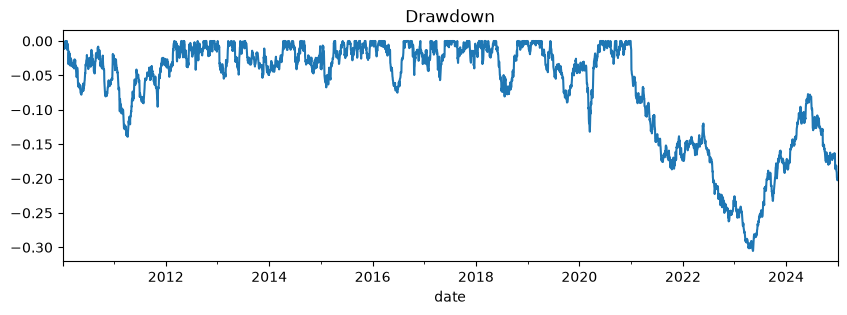

In [18]:
g = (1 + port).cumprod(); dd = g / g.cummax() - 1
trough = dd.idxmin(); peak = g.loc[:trough].idxmax(); rec = g.loc[trough:][g.loc[trough:] >= g.loc[peak]].index
print(f"max drawdown {dd.min():.1%}: peak {peak.date()}, trough {trough.date()}, recovered {rec[0].date() if len(rec) else 'not yet'}")
print(f"Calmar ratio (annual return / |max drawdown|): {port.mean() * 252 / abs(dd.min()):.2f}")
dd.plot(figsize=(10, 3), title="Drawdown"); plt.show()

## 8. A factor risk model
Explain each asset with two factors (world equity and global bonds), then split portfolio variance into a **systematic** part (factor exposures) and an **idiosyncratic** part.

In [19]:
fac = [c for c in ["WORLD_EQUITY", "GLOBAL_BONDS"] if c in rets.columns] or list(rets.columns[:2])
Fm = rets[fac]; B, spec = [], []
for a in W.index:
    m = sm.OLS(rets[a], sm.add_constant(Fm)).fit(); B.append(m.params[fac].to_numpy()); spec.append(m.resid.var())
B = np.array(B); D = np.diag(spec); SF = Fm.cov().to_numpy()
b_p = w @ B
sys_var, idio_var = b_p @ SF @ b_p, w @ D @ w
print(pd.DataFrame(B, index=W.index, columns=[f"beta to {f}" for f in fac]).round(2))
print(f"portfolio factor exposures {dict(zip(fac, b_p.round(3)))}")
print(f"systematic share of variance {sys_var / (sys_var + idio_var):.1%} | idiosyncratic {idio_var / (sys_var + idio_var):.1%}")

                   beta to WORLD_EQUITY  beta to GLOBAL_BONDS
CH_EQUITY                          0.82                  0.24
WORLD_EQUITY                       1.00                 -0.00
EM_EQUITY                          1.05                  0.00
CHF_BONDS                         -0.01                  0.58
GLOBAL_BONDS                       0.00                  1.00
GOLD                               0.03                  0.77
SWISS_REAL_ESTATE                  0.31                  0.59
COMMODITIES                        0.48                 -0.34
portfolio factor exposures {'WORLD_EQUITY': np.float64(0.471), 'GLOBAL_BONDS': np.float64(0.373)}
systematic share of variance 92.0% | idiosyncratic 8.0%


## 9. Performance attribution
### 9a. Brinson–Fachler: why did we beat the benchmark?
For each sector: **allocation** $(w_p - w_b)(r_b - R_b)$, **selection** $w_b(r_p - r_b)$, **interaction** $(w_p - w_b)(r_p - r_b)$.
They add up exactly to the active return.

In [20]:
br = pd.DataFrame({"w_p": [0.30, 0.20, 0.25, 0.25], "w_b": [0.25, 0.30, 0.25, 0.20],
                   "r_p": [0.08, 0.05, 0.10, 0.15], "r_b": [0.06, 0.06, 0.09, 0.12]},
                  index=["Financials", "Health care", "Industrials", "Technology"])
R_p, R_b = br.w_p @ br.r_p, br.w_b @ br.r_b
print(br); print(f"portfolio return {R_p:.2%}, benchmark {R_b:.2%}, active {R_p - R_b:.2%}")

              w_p   w_b   r_p   r_b
Financials   0.30  0.25  0.08  0.06
Health care  0.20  0.30  0.05  0.06
Industrials  0.25  0.25  0.10  0.09
Technology   0.25  0.20  0.15  0.12
portfolio return 9.65%, benchmark 7.95%, active 1.70%


### Exercise 5

Compute the **total allocation effect** (sum over sectors of (w_p − w_b)(r_b − R_b)) and store it in `total_allocation`. Then compute selection and interaction and check that the three add up to the active return.

In [21]:
# Your code here

In [22]:
check("18.5");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 18.5: not answered yet. Store your answer in `total_allocation`.


### 9b. Returns-based: tracking error, information ratio, alpha

In [23]:
bench = rets[W.index] @ pd.Series(1 / len(W), index=W.index)        # benchmark: equal weights
active = port - bench
te = active.std() * np.sqrt(252); ir = active.mean() * 252 / te
reg = sm.OLS(port, sm.add_constant(bench)).fit()
print(f"active return {active.mean() * 252:.2%} a year | tracking error {te:.2%} | information ratio {ir:.2f}")
print(f"alpha {reg.params['const'] * 252:.2%} a year (t = {reg.tvalues['const']:.2f}), beta to benchmark {reg.params.iloc[1]:.2f}")

active return 0.44% a year | tracking error 2.62% | information ratio 0.17
alpha 0.93% a year (t = 1.50), beta to benchmark 0.90


**Your turn (no checker):**
1. Compute 99% 1-day VaR with **filtered historical simulation**: divide returns by their EWMA volatility, take the 1% quantile, then rescale by today's volatility. Backtest it like Section 4.
2. Add a scenario of your own (e.g. CHF appreciates 15%: foreign assets −15% in CHF terms). Which part of the portfolio hurts most?
3. Write the one-paragraph risk summary a CIO would read: VaR, ES, worst stress, biggest risk contributor.

---
## Solutions

In [24]:
var_hist_99 = -np.quantile(port, 0.01)
es_hist_99 = -port[port <= np.quantile(port, 0.01)].mean()
var_norm_99 = -(port.mean() + stats.norm.ppf(0.01) * port.std())
print(f"1-3) historical VaR {var_hist_99:.4f} | ES {es_hist_99:.4f} | normal VaR {var_norm_99:.4f} → normal understates the tail")

def kupiec_pvalue(x, n, p):
    pi = x / n
    ll0 = (n - x) * np.log(1 - p) + x * np.log(p)
    ll1 = (n - x) * np.log(1 - pi) + (x * np.log(pi) if x > 0 else 0.0)
    return 1 - stats.chi2.cdf(-2 * (ll0 - ll1), 1)

alloc = (br.w_p - br.w_b) * (br.r_b - R_b); sel = br.w_b * (br.r_p - br.r_b); inter = (br.w_p - br.w_b) * (br.r_p - br.r_b)
total_allocation = alloc.sum()
print(f"5) allocation {alloc.sum():.2%} + selection {sel.sum():.2%} + interaction {inter.sum():.2%} = {alloc.sum() + sel.sum() + inter.sum():.2%} (active {R_p - R_b:.2%})")
check_all("18")

1-3) historical VaR 0.0145 | ES 0.0185 | normal VaR 0.0125 → normal understates the tail
5) allocation 0.30% + selection 1.05% + interaction 0.35% = 1.70% (active 1.70%)


✅ Exercise 18.1: correct.
✅ Exercise 18.2: correct.
✅ Exercise 18.3: correct.
✅ Exercise 18.4: correct.
✅ Exercise 18.5: correct.

5 of 5 exercises correct.
